<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/AIgasprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-assisted gas-processing simulation and design with NeqSim

This notebook turns a short conceptual AI sketch into an executable hybrid engineering
workflow. NeqSim remains the physics authority. A transparent quadratic surrogate learns
from NeqSim cases, screens many operating points quickly, and sends every recommended point
back to NeqSim for independent verification.

## Intended audience, prerequisites, and learning objectives

**Audience.** Process, production, and data engineers who know basic phase equilibrium and
Python. No machine-learning package is required.

**Prerequisites.** Familiarity with pressure, temperature, mass flow, separation, and gas
compression is useful. A clean Google Colab runtime is sufficient.

By the end, you will be able to:

* build a connected choke–cooler–three-phase-separator–compressor process in NeqSim;
* generate an auditable design of experiments from physically consistent simulations;
* fit and test a regularized quadratic surrogate with NumPy;
* distinguish interpolation, extrapolation, and model-form error;
* screen a constrained operating envelope and revalidate the best candidate in NeqSim;
* use model residuals as synthetic anomaly indicators without presenting them as alarms.

## 1. Setup for Google Colab

The setup cell installs the current public PyPI package only when NeqSim is unavailable.
Validation for this published artifact uses a separate clean, hash-verified environment;
the notebook itself has no hidden wheelhouse, local JAR, secret, or proprietary-data
dependency.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
from importlib.metadata import version
import platform
import subprocess

neqsim_version = version("neqsim")
python_version = platform.python_version()
java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

print(f"NeqSim: {neqsim_version}")
print(f"Python: {python_version}")
print(f"Java: {java_version}")

NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## 2. From a language-model suggestion to an engineering workflow

The following preserved text was the original notebook's conceptual content. It correctly
names data preparation, training, validation, implementation, optimization, and continuous
learning. The executable sections below add the missing physics, units, numerical checks,
applicability limits, and independent verification.

# ChatGPT: how to use AI for gas processing simulation?
Gas processing simulation involves modeling the behavior of gases and their interactions with
equipment such as pipelines, compressors, and separators. AI can be used to enhance the accuracy
and efficiency of gas processing simulation by improving the modeling techniques and reducing the
computational time required.

Here are some steps on how to use AI for gas processing simulation:

* Collect and preprocess data: Collect data on gas properties, equipment specifications, and
  operating conditions. Preprocess the data to remove any outliers or inconsistencies.

* Train machine learning models: Use machine learning algorithms such as regression, decision
  trees, or neural networks to create models that can predict the behavior of the gas and equipment
  under various conditions.

* Validate the models: Test the accuracy of the models by comparing their predictions to real-world
  data.

* Implement the models in a simulation software: Incorporate the AI models into a gas processing
  simulation software to improve the accuracy of the simulation.

* Optimize the simulation: Use the simulation software to optimize the gas processing operations by
  identifying potential bottlenecks, optimizing equipment design, and improving energy efficiency.

* Continuous learning: Continuously monitor the performance of the AI models and update them with
  new data to ensure that they remain accurate and reliable.

Overall, AI can be a powerful tool for gas processing simulation by providing more accurate
predictions and reducing computational time. However, it is important to validate the models and
continuously monitor their performance to ensure that they are reliable and effective.

# Examples of use of AI technologies with NeqSim

In this example, “AI” means a supervised response-surface model rather than a generative
language model. The surrogate is useful because it evaluates thousands of candidates in
milliseconds, but its authority is deliberately limited:

1. NeqSim generates the training and validation labels.
2. Held-out NeqSim cases quantify predictive error.
3. Search is restricted to the sampled input bounds.
4. The selected candidate is rerun in NeqSim before use.
5. A process engineer must still approve assumptions and constraints.

## 3. Engineering basis

A synthetic rich wellstream enters at $90\ \mathrm{bara}$ and $333.15\ \mathrm{K}$.
The controllable variables are feed mass rate $\dot{m}_f$ in $\mathrm{kg/s}$, separator
pressure $P_s$ in $\mathrm{bara}$, and separator temperature $T_s$ in $\mathrm{K}$.

The valve is treated as isenthalpic:

$$
h_{out} = h_{in}
$$

The cooler imposes $T_s$, the equilibrium separator divides the feed into gas, oil, and
aqueous products, and the compressor raises the gas to $120\ \mathrm{bara}$ with fixed
isentropic efficiency $\eta_s=0.78$. Separator mass closure is

$$
\dot{m}_f = \dot{m}_g + \dot{m}_o + \dot{m}_w
$$

All results are equilibrium, steady-state screening results. They omit equipment dynamics,
control interactions, compressor maps, hydrate kinetics, corrosion, economics, and
measurement uncertainty.

In [3]:
import itertools

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim.process import (
    compressor,
    cooler,
    newProcess,
    separator3phase,
    stream,
    valve,
)
from neqsim.thermo import fluid

pd.set_option("display.max_columns", 20)
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "red": "#D55E00",
    "gray": "#666666",
}

## 4. Fluid representation and process objects

`fluid("pr")` creates a Peng–Robinson thermodynamic system. This cubic equation of state is a
practical screening choice for a nonpolar hydrocarbon-rich wellstream. The classic mixing
rule is explicit, and multiphase checking is enabled because both hydrocarbon liquid and
water are expected.

NeqSim represents the flowsheet with connected objects: `Stream` carries the thermodynamic
state, `ThrottlingValve` changes pressure at constant enthalpy, `Cooler` sets temperature,
`ThreePhaseSeparator` performs phase splitting, and `Compressor` calculates the gas
discharge state and power. `ProcessSystem.run()` executes the connected solver workflow.

In [4]:
WELLSTREAM_COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.650,
    "ethane": 0.100,
    "propane": 0.075,
    "n-butane": 0.050,
    "n-pentane": 0.035,
    "n-hexane": 0.025,
    "n-heptane": 0.020,
    "water": 0.015,
}

composition_sum = sum(WELLSTREAM_COMPOSITION.values())
assert np.isclose(composition_sum, 1.0, atol=1.0e-12)
print(f"Wellstream mole-fraction sum: {composition_sum:.12f}")

Wellstream mole-fraction sum: 1.000000000000


In [5]:
def build_wellstream(feed_rate_kg_s: float):
    wellstream = fluid(
        "pr",
        temperature=333.15,
        pressure=90.0,
    )

    for component_name, mole_fraction in WELLSTREAM_COMPOSITION.items():
        wellstream.addComponent(
            component_name,
            mole_fraction,
        )

    wellstream.setMixingRule("classic")
    wellstream.setMultiPhaseCheck(True)
    wellstream.setTotalFlowRate(
        float(feed_rate_kg_s),
        "kg/sec",
    )
    return wellstream


reference_fluid = build_wellstream(75.0)
print(
    "Reference fluid:",
    f"{reference_fluid.getNumberOfComponents()} components,",
    "Peng–Robinson EOS",
)

Reference fluid: 10 components, Peng–Robinson EOS


## 5. Reusable NeqSim calculation

The function below creates new fluid and equipment objects for every case. This avoids
hidden mutable state between training, test, and verification runs. Returned values use
explicit SI-compatible engineering units; pressure remains in the common absolute unit
`bara`, as stated in every label.

In [6]:
def run_neqsim_case(
    feed_rate_kg_s: float,
    separator_pressure_bara: float,
    separator_temperature_k: float,
) -> dict[str, float]:
    process_model = newProcess(
        "AI gas-processing case"
    )
    feed_fluid = build_wellstream(feed_rate_kg_s)
    feed_stream = stream(
        "raw wellstream",
        feed_fluid,
        process=process_model,
    )
    inlet_choke = valve(
        "inlet choke",
        feed_stream,
        p=separator_pressure_bara,
        process=process_model,
    )
    inlet_cooler = cooler(
        "inlet cooler",
        inlet_choke.getOutletStream(),
        process=process_model,
    )
    inlet_cooler.setOutTemperature(separator_temperature_k)
    inlet_separator = separator3phase(
        "inlet three-phase separator",
        inlet_cooler.getOutletStream(),
        process=process_model,
    )
    export_compressor = compressor(
        "export gas compressor",
        inlet_separator.getGasOutStream(),
        pres=120.0,
        process=process_model,
    )
    export_compressor.setIsentropicEfficiency(0.78)

    process_model.run()

    feed_mass_rate = feed_stream.getFlowRate("kg/sec")
    gas_mass_rate = inlet_separator.getGasOutStream().getFlowRate("kg/sec")
    oil_mass_rate = inlet_separator.getOilOutStream().getFlowRate("kg/sec")
    water_mass_rate = inlet_separator.getWaterOutStream().getFlowRate("kg/sec")
    liquid_mass_rate = oil_mass_rate + water_mass_rate
    total_product_rate = gas_mass_rate + liquid_mass_rate

    return {
        "feed_rate_kg_s": feed_mass_rate,
        "separator_pressure_bara": separator_pressure_bara,
        "separator_temperature_k": separator_temperature_k,
        "gas_rate_kg_s": gas_mass_rate,
        "oil_rate_kg_s": oil_mass_rate,
        "water_rate_kg_s": water_mass_rate,
        "liquid_rate_kg_s": liquid_mass_rate,
        "compressor_power_mw": export_compressor.getPower() / 1.0e6,
        "compressor_outlet_temperature_k": (
            export_compressor.getOutletStream().getTemperature()
        ),
        "mass_residual_kg_s": feed_mass_rate - total_product_rate,
    }

In [7]:
reference_result = run_neqsim_case(
    feed_rate_kg_s=75.0,
    separator_pressure_bara=52.0,
    separator_temperature_k=300.15,
)

display(pd.DataFrame([reference_result]).round(6))

,feed_rate_kg_s,separator_pressure_bara,separator_temperature_k,gas_rate_kg_s,oil_rate_kg_s,water_rate_kg_s,liquid_rate_kg_s,compressor_power_mw,compressor_outlet_temperature_k,mass_residual_kg_s
0,75.0,52.0,300.15,45.018386,29.279434,0.70218,29.981614,5.095969,369.774722,0.0


In [8]:
reference_relative_residual = abs(
    reference_result["mass_residual_kg_s"]
) / reference_result["feed_rate_kg_s"]

assert reference_result["gas_rate_kg_s"] > 0.0
assert reference_result["oil_rate_kg_s"] > 0.0
assert reference_result["water_rate_kg_s"] > 0.0
assert reference_result["compressor_power_mw"] > 0.0
assert reference_result["compressor_outlet_temperature_k"] > 300.15
assert reference_relative_residual < 1.0e-9

print(f"Relative separator mass residual: {reference_relative_residual:.3e}")

Relative separator mass residual: 1.004e-14


**Interpretation.** Positive gas, oil, and water products confirm that the selected reference
point exercises a genuine three-phase process. The compressor requires positive power and
heats the gas. The mass residual is near floating-point precision, making the result suitable
as a training label.

## 6. Visual 1 — physics and AI workflow

The workflow separates the trusted first-principles calculation from the approximate
surrogate. Only the NeqSim rerun can approve a recommendation.

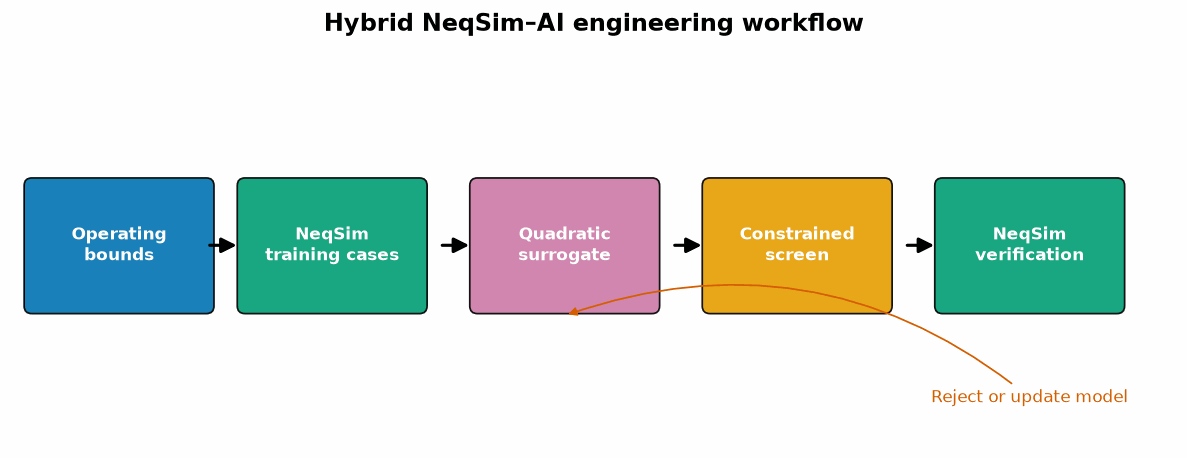

In [9]:
figure, axis = plt.subplots(figsize=(12, 4.2))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.2)
axis.axis("off")

workflow_nodes = [
    (0.2, "Operating\nbounds", COLORS["blue"]),
    (2.4, "NeqSim\ntraining cases", COLORS["green"]),
    (4.8, "Quadratic\nsurrogate", COLORS["purple"]),
    (7.2, "Constrained\nscreen", COLORS["orange"]),
    (9.6, "NeqSim\nverification", COLORS["green"]),
]

for x_position, label, color in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, 1.45),
        1.8,
        1.25,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.9,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.9,
        2.08,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )

for start_x in [2.0, 4.4, 6.8, 9.2]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 2.08),
            (start_x + 0.35, 2.08),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=1.8,
            color="black",
        )
    )

axis.annotate(
    "Reject or update model",
    xy=(5.7, 1.35),
    xytext=(10.5, 0.45),
    ha="center",
    color=COLORS["red"],
    arrowprops={
        "arrowstyle":"-|>",
        "connectionstyle":"arc3,rad=0.28",
        "color":COLORS["red"],
    },
)
axis.set_title(
    "Hybrid NeqSim–AI engineering workflow",
    fontsize=14,
    weight="bold",
)
plt.show()

**Engineering conclusion.** The surrogate accelerates screening but does not replace
thermodynamics. This arrangement also makes retraining auditable: new measurements or
expanded NeqSim cases enter upstream of validation, not directly into the recommendation.

## 7. Visual 2 — connected process model

The same physical topology is rebuilt for each sample so every label comes from identical
model structure and differs only in the three declared inputs.

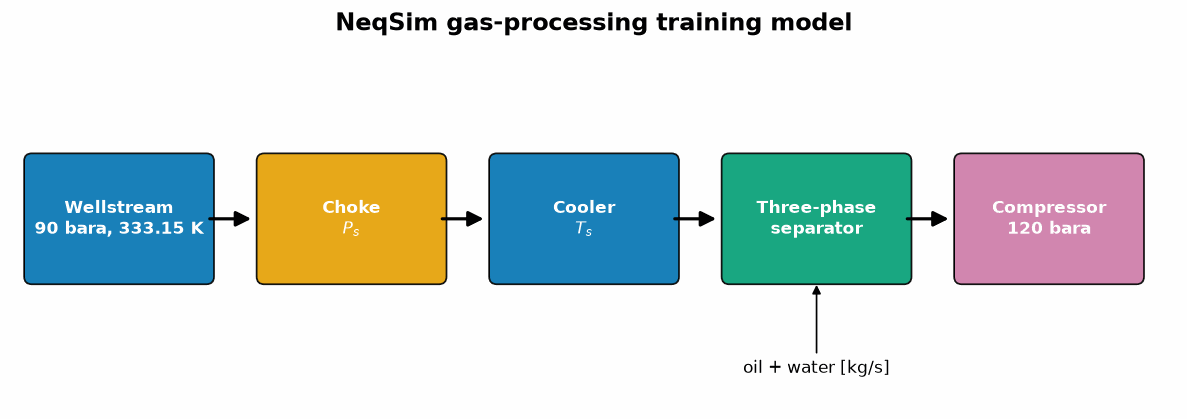

In [10]:
figure, axis = plt.subplots(figsize=(12, 3.8))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 3.8)
axis.axis("off")

process_nodes = [
    (0.2, "Wellstream\n90 bara, 333.15 K", COLORS["blue"]),
    (2.6, "Choke\n$P_s$", COLORS["orange"]),
    (5.0, "Cooler\n$T_s$", COLORS["blue"]),
    (7.4, "Three-phase\nseparator", COLORS["green"]),
    (9.8, "Compressor\n120 bara", COLORS["purple"]),
]

for x_position, label, color in process_nodes:
    box = FancyBboxPatch(
        (x_position, 1.35),
        1.8,
        1.2,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.9,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.9,
        1.95,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )

for start_x in [2.0, 4.4, 6.8, 9.2]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 1.95),
            (start_x + 0.5, 1.95),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=1.8,
            color="black",
        )
    )

axis.annotate(
    "oil + water [kg/s]",
    xy=(8.3, 1.3),
    xytext=(8.3, 0.35),
    ha="center",
    arrowprops={
        "arrowstyle":"-|>",
        "color":"black",
    },
)
axis.set_title(
    "NeqSim gas-processing training model",
    fontsize=14,
    weight="bold",
)
plt.show()

## 8. Design of experiments

Training bounds are deliberately compact: $50$–$100\ \mathrm{kg/s}$ feed,
$42$–$66\ \mathrm{bara}$ separator pressure, and $288.15$–$312.15\ \mathrm{K}$
separator temperature. A full-factorial design exposes main effects, curvature, and
interactions. Twelve interior held-out points are never used to estimate coefficients.

In [11]:
training_feed_rates = np.linspace(50.0, 100.0, 5)
training_pressures = np.linspace(42.0, 66.0, 4)
training_temperatures = np.linspace(288.15, 312.15, 3)

training_cases = list(
    itertools.product(
        training_feed_rates,
        training_pressures,
        training_temperatures,
    )
)

print(f"Training cases: {len(training_cases)}")

Training cases: 60


In [12]:
training_results = []

for case_index, case in enumerate(training_cases, start=1):
    training_results.append(run_neqsim_case(*case))
    if case_index % 15 == 0:
        print(f"Completed {case_index} of {len(training_cases)} cases")

training_frame = pd.DataFrame(training_results)
display(training_frame.head().round(5))

Completed 15 of 60 cases
Completed 30 of 60 cases
Completed 45 of 60 cases
Completed 60 of 60 cases


,feed_rate_kg_s,separator_pressure_bara,separator_temperature_k,gas_rate_kg_s,oil_rate_kg_s,water_rate_kg_s,liquid_rate_kg_s,compressor_power_mw,compressor_outlet_temperature_k,mass_residual_kg_s
0,50.0,42.0,288.15,28.89077,20.63297,0.47627,21.10923,4.24428,376.29729,0.0
1,50.0,42.0,300.15,31.28709,18.24871,0.46421,18.71291,4.63299,387.97554,0.0
2,50.0,42.0,312.15,33.82696,15.73190,0.44114,16.17304,5.02173,399.26142,0.0
3,50.0,50.0,288.15,27.81277,21.70949,0.47774,22.18723,3.28402,361.16135,0.0
4,50.0,50.0,300.15,30.24939,19.28314,0.46747,19.75061,3.61532,373.15218,0.0


In [13]:
maximum_relative_mass_residual = (
    training_frame["mass_residual_kg_s"].abs()
    / training_frame["feed_rate_kg_s"]
).max()

assert np.isfinite(training_frame.to_numpy()).all()
assert (training_frame["gas_rate_kg_s"] > 0.0).all()
assert (training_frame["oil_rate_kg_s"] > 0.0).all()
assert (training_frame["water_rate_kg_s"] > 0.0).all()
assert (training_frame["compressor_power_mw"] > 0.0).all()
assert maximum_relative_mass_residual < 1.0e-9

print(
    "Maximum relative mass residual:",
    f"{maximum_relative_mass_residual:.3e}",
)

Maximum relative mass residual: 3.638e-14


## 9. Visual 3 — sampled physics

These plots show the raw NeqSim labels before any regression. They help detect impossible
values, discontinuities, and poorly covered regions that a metric alone could hide.

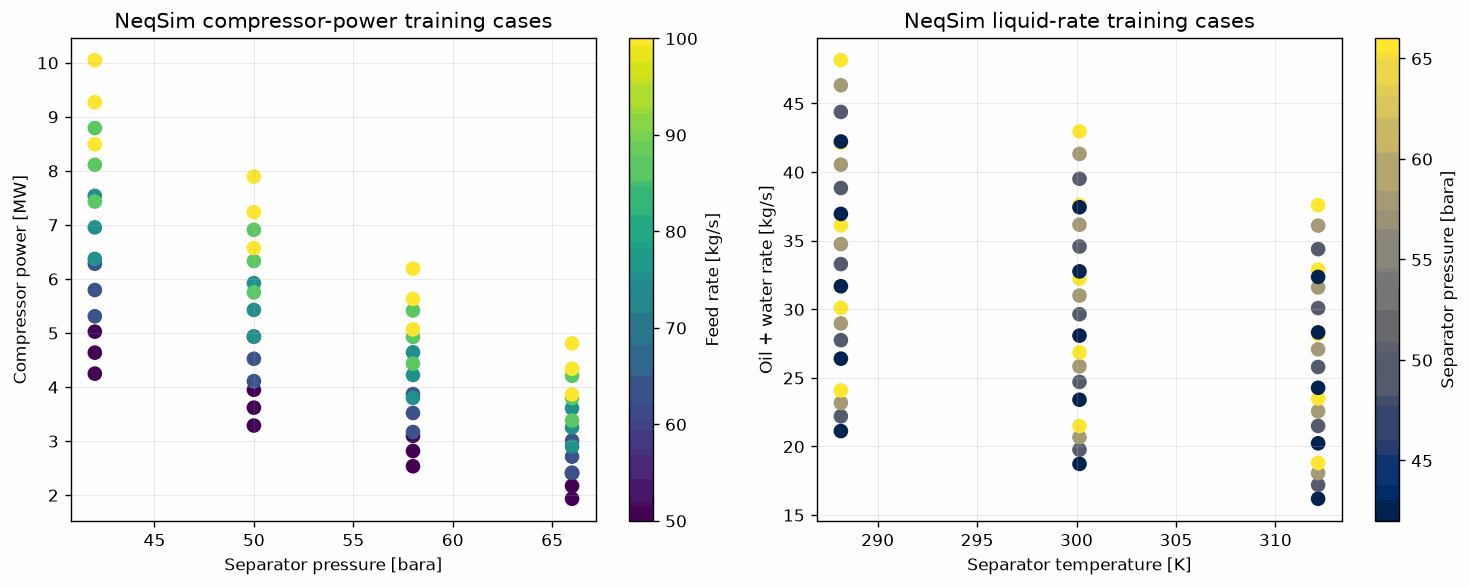

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

scatter_power = axes[0].scatter(
    training_frame["separator_pressure_bara"],
    training_frame["compressor_power_mw"],
    c=training_frame["feed_rate_kg_s"],
    cmap="viridis",
    s=55,
)
axes[0].set_title("NeqSim compressor-power training cases")
axes[0].set_xlabel("Separator pressure [bara]")
axes[0].set_ylabel("Compressor power [MW]")
power_colorbar = figure.colorbar(scatter_power, ax=axes[0])
power_colorbar.set_label("Feed rate [kg/s]")

scatter_liquid = axes[1].scatter(
    training_frame["separator_temperature_k"],
    training_frame["liquid_rate_kg_s"],
    c=training_frame["separator_pressure_bara"],
    cmap="cividis",
    s=55,
)
axes[1].set_title("NeqSim liquid-rate training cases")
axes[1].set_xlabel("Separator temperature [K]")
axes[1].set_ylabel("Oil + water rate [kg/s]")
liquid_colorbar = figure.colorbar(scatter_liquid, ax=axes[1])
liquid_colorbar.set_label("Separator pressure [bara]")

figure.tight_layout()
plt.show()

**Interpretation.** Higher separator pressure reduces compression ratio and therefore power.
Colder separation generally moves more material into liquid. Feed rate changes both product
rates and power. These coupled trends motivate interaction terms in the surrogate.

## 10. Transparent quadratic surrogate

Inputs are centered and scaled before constructing constant, linear, square, and pairwise
interaction terms. For a response vector $y$,

$$
\hat{\beta} = \left(X^T X + \lambda I\right)^{-1} X^T y
$$

where $X$ is the feature matrix, $\hat{\beta}$ contains fitted coefficients, and
$\lambda=10^{-8}$ is a small ridge term. The intercept is not penalized. This model is
intentionally interpretable and dependency-light; it is not assumed to be universally
superior to trees, Gaussian processes, or neural networks.

In [15]:
INPUT_COLUMNS = [
    "feed_rate_kg_s",
    "separator_pressure_bara",
    "separator_temperature_k",
]
TARGET_COLUMNS = [
    "gas_rate_kg_s",
    "liquid_rate_kg_s",
    "compressor_power_mw",
    "compressor_outlet_temperature_k",
]

input_center = training_frame[INPUT_COLUMNS].mean().to_numpy()
input_scale = training_frame[INPUT_COLUMNS].std(ddof=0).to_numpy()

In [16]:
def quadratic_features(input_values: np.ndarray) -> np.ndarray:
    standardized = (input_values - input_center) / input_scale
    feed = standardized[:, 0]
    pressure = standardized[:, 1]
    temperature = standardized[:, 2]

    return np.column_stack(
        [
            np.ones(len(standardized)),
            feed,
            pressure,
            temperature,
            feed**2,
            pressure**2,
            temperature**2,
            feed * pressure,
            feed * temperature,
            pressure * temperature,
        ]
    )


training_inputs = training_frame[INPUT_COLUMNS].to_numpy()
training_targets = training_frame[TARGET_COLUMNS].to_numpy()
training_features = quadratic_features(training_inputs)

ridge_matrix = np.eye(training_features.shape[1]) * 1.0e-8
ridge_matrix[0, 0] = 0.0
surrogate_coefficients = np.linalg.solve(
    training_features.T @ training_features + ridge_matrix,
    training_features.T @ training_targets,
)

print(f"Feature count: {training_features.shape[1]}")
print(f"Target count: {surrogate_coefficients.shape[1]}")

Feature count: 10
Target count: 4


In [17]:
def predict_surrogate(input_frame: pd.DataFrame) -> pd.DataFrame:
    input_values = input_frame[INPUT_COLUMNS].to_numpy()
    predictions = quadratic_features(input_values) @ surrogate_coefficients

    prediction_frame = input_frame[INPUT_COLUMNS].reset_index(drop=True).copy()
    for target_index, target_name in enumerate(TARGET_COLUMNS):
        prediction_frame[target_name] = predictions[:, target_index]
    return prediction_frame

## 11. Independent validation

The test points lie strictly inside the training bounds but do not coincide with the
factorial grid. Root-mean-square error and coefficient of determination are

$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2}
$$

$$
R^2 = 1-\frac{\sum_{i=1}^{n}(\hat{y}_i-y_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

Validation against simulator-generated labels measures interpolation fidelity, not
agreement with plant data.

In [18]:
test_cases = [
    (55.0, 46.0, 294.15),
    (58.0, 62.0, 306.15),
    (64.0, 54.0, 290.15),
    (68.0, 48.0, 308.15),
    (72.0, 64.0, 298.15),
    (76.0, 56.0, 310.15),
    (81.0, 44.0, 302.15),
    (84.0, 60.0, 292.15),
    (88.0, 52.0, 304.15),
    (92.0, 46.0, 296.15),
    (96.0, 58.0, 306.15),
    (98.0, 64.0, 300.15),
]

test_results = [
    run_neqsim_case(*case)
    for case in test_cases
]
test_frame = pd.DataFrame(test_results)
test_predictions = predict_surrogate(test_frame)
print(f"Held-out NeqSim cases: {len(test_frame)}")

Held-out NeqSim cases: 12


In [19]:
validation_rows = []

for target_name in TARGET_COLUMNS:
    observed = test_frame[target_name].to_numpy()
    predicted = test_predictions[target_name].to_numpy()
    residual = predicted - observed
    rmse = float(np.sqrt(np.mean(residual**2)))
    denominator = float(np.sum((observed - observed.mean()) ** 2))
    r_squared = 1.0 - float(np.sum(residual**2)) / denominator
    validation_rows.append(
        {
            "target": target_name,
            "RMSE": rmse,
            "R_squared": r_squared,
            "maximum_absolute_error": float(np.max(np.abs(residual))),
        }
    )

validation_frame = pd.DataFrame(validation_rows)
display(validation_frame.round(6))

,target,RMSE,R_squared,maximum_absolute_error
0,gas_rate_kg_s,0.024592,0.999992,0.048459
1,liquid_rate_kg_s,0.024592,0.999984,0.048459
2,compressor_power_mw,0.022866,0.999714,0.037998
3,compressor_outlet_temperature_k,0.056389,0.999980,0.078243


## 12. Visual 4 — held-out parity

Each marker is an independent NeqSim test case. The diagonal is perfect agreement; the
shaded-free presentation avoids implying uncertainty intervals that were not calculated.

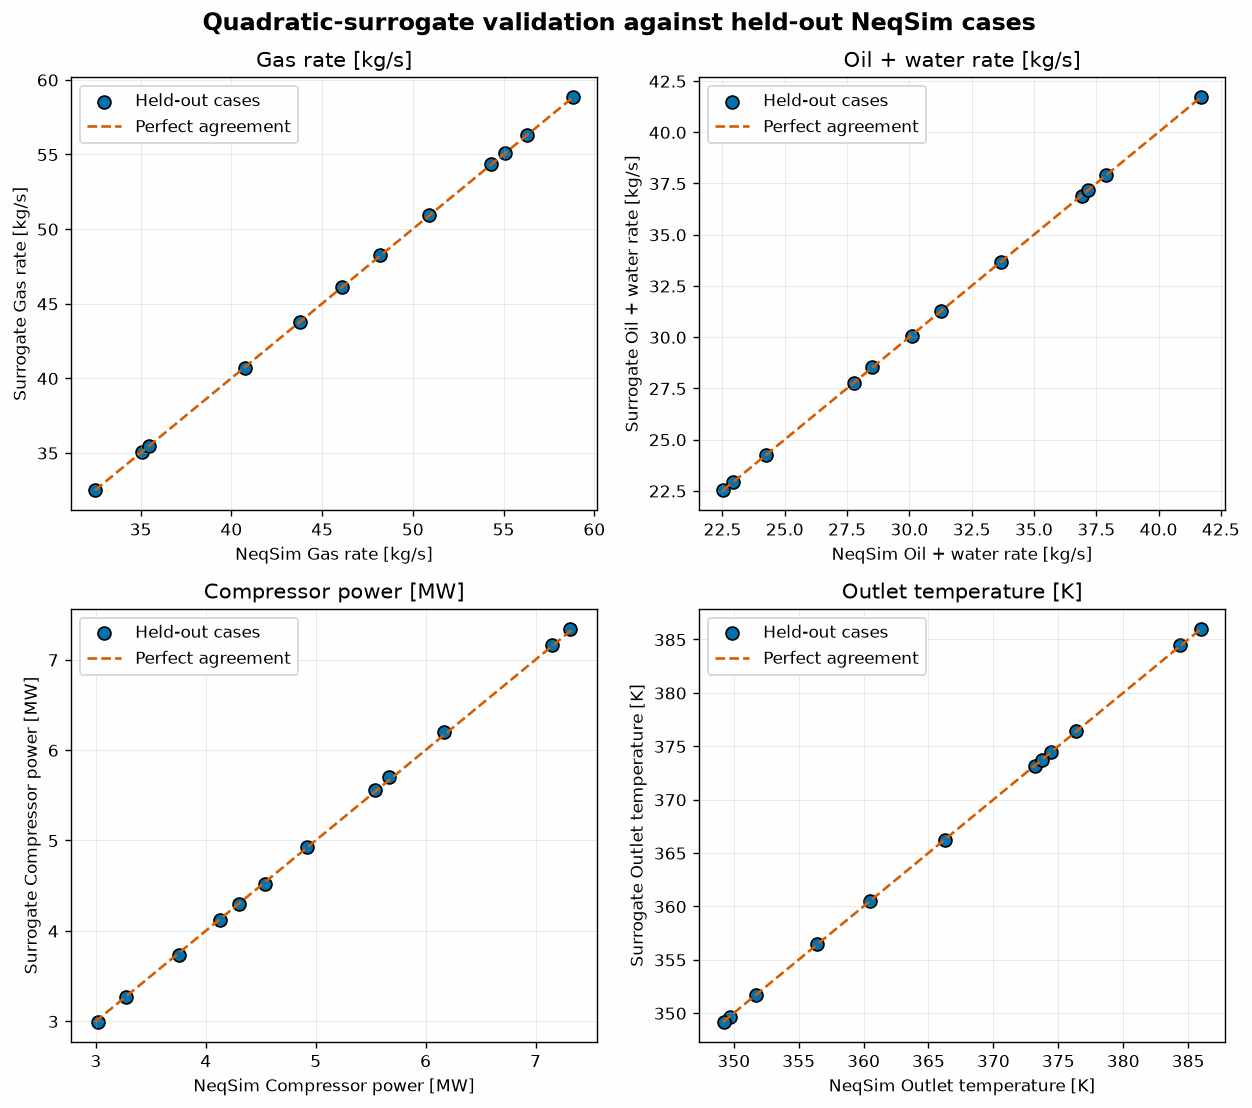

In [20]:
figure, axes = plt.subplots(2, 2, figsize=(10, 9))

target_labels = {
    "gas_rate_kg_s": "Gas rate [kg/s]",
    "liquid_rate_kg_s": "Oil + water rate [kg/s]",
    "compressor_power_mw": "Compressor power [MW]",
    "compressor_outlet_temperature_k": "Outlet temperature [K]",
}

for axis, target_name in zip(axes.flat, TARGET_COLUMNS):
    observed = test_frame[target_name]
    predicted = test_predictions[target_name]
    lower = min(observed.min(), predicted.min())
    upper = max(observed.max(), predicted.max())

    axis.scatter(
        observed,
        predicted,
        color=COLORS["blue"],
        edgecolor="black",
        s=55,
        label="Held-out cases",
    )
    axis.plot(
        [lower, upper],
        [lower, upper],
        color=COLORS["red"],
        linestyle="--",
        label="Perfect agreement",
    )
    axis.set_title(target_labels[target_name])
    axis.set_xlabel(f"NeqSim {target_labels[target_name]}")
    axis.set_ylabel(f"Surrogate {target_labels[target_name]}")
    axis.legend()

figure.suptitle(
    "Quadratic-surrogate validation against held-out NeqSim cases",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

In [21]:
minimum_r_squared = validation_frame["R_squared"].min()
power_rmse = validation_frame.loc[
    validation_frame["target"] == "compressor_power_mw",
    "RMSE",
].iloc[0]
gas_rate_rmse = validation_frame.loc[
    validation_frame["target"] == "gas_rate_kg_s",
    "RMSE",
].iloc[0]

assert minimum_r_squared > 0.995
assert power_rmse < 0.08
assert gas_rate_rmse < 0.25

print(f"Minimum held-out R²: {minimum_r_squared:.6f}")
print(f"Compressor-power RMSE: {power_rmse:.6f} MW")

Minimum held-out R²: 0.999714
Compressor-power RMSE: 0.022866 MW


**Interpretation.** The quadratic model is accepted only for interpolation inside the stated
bounds. High $R^2$ is not enough by itself, so absolute errors in engineering units are also
checked. A future workflow using plant data should split observations by time or campaign to
avoid leakage.

## 13. Constrained operating-envelope search

The screening objective is maximum predicted gas export subject to:

* compressor power no greater than $4.75\ \mathrm{MW}$;
* compressor outlet temperature no greater than $375\ \mathrm{K}$;
* oil-plus-water rate at least $35\ \mathrm{kg/s}$;
* all inputs remaining inside the sampled bounds.

These are tutorial constraints, not equipment limits. The grid is dense enough for screening
but does not certify a mathematical global optimum.

In [22]:
candidate_feed_rates = np.linspace(50.0, 100.0, 21)
candidate_pressures = np.linspace(42.0, 66.0, 25)
candidate_temperatures = np.linspace(288.15, 312.15, 25)

candidate_frame = pd.DataFrame(
    itertools.product(
        candidate_feed_rates,
        candidate_pressures,
        candidate_temperatures,
    ),
    columns=INPUT_COLUMNS,
)
candidate_predictions = predict_surrogate(candidate_frame)

candidate_predictions["feasible"] = (
    (candidate_predictions["compressor_power_mw"] <= 4.75)
    & (
        candidate_predictions["compressor_outlet_temperature_k"]
        <= 375.0
    )
    & (candidate_predictions["liquid_rate_kg_s"] >= 35.0)
)

feasible_candidates = candidate_predictions.loc[
    candidate_predictions["feasible"]
].copy()
best_surrogate_candidate = feasible_candidates.sort_values(
    "gas_rate_kg_s",
    ascending=False,
).iloc[0]

print(f"Candidates screened: {len(candidate_predictions):,}")
print(f"Surrogate-feasible candidates: {len(feasible_candidates):,}")
display(best_surrogate_candidate.to_frame("value").round(6))

Candidates screened: 13,125
Surrogate-feasible candidates: 1,191


,value
feed_rate_kg_s,100.0
separator_pressure_bara,66.0
separator_temperature_k,310.15
gas_rate_kg_s,61.436269
liquid_rate_kg_s,38.563731
compressor_power_mw,4.712334
compressor_outlet_temperature_k,359.14579
feasible,True


## 14. Visual 5 — feasible envelope

The plot projects a three-dimensional search onto feed rate and pressure. Color shows
predicted gas export, while gray points violate at least one tutorial constraint. Because
temperature is hidden in this projection, the highlighted optimum should be interpreted
with its full tabulated coordinates.

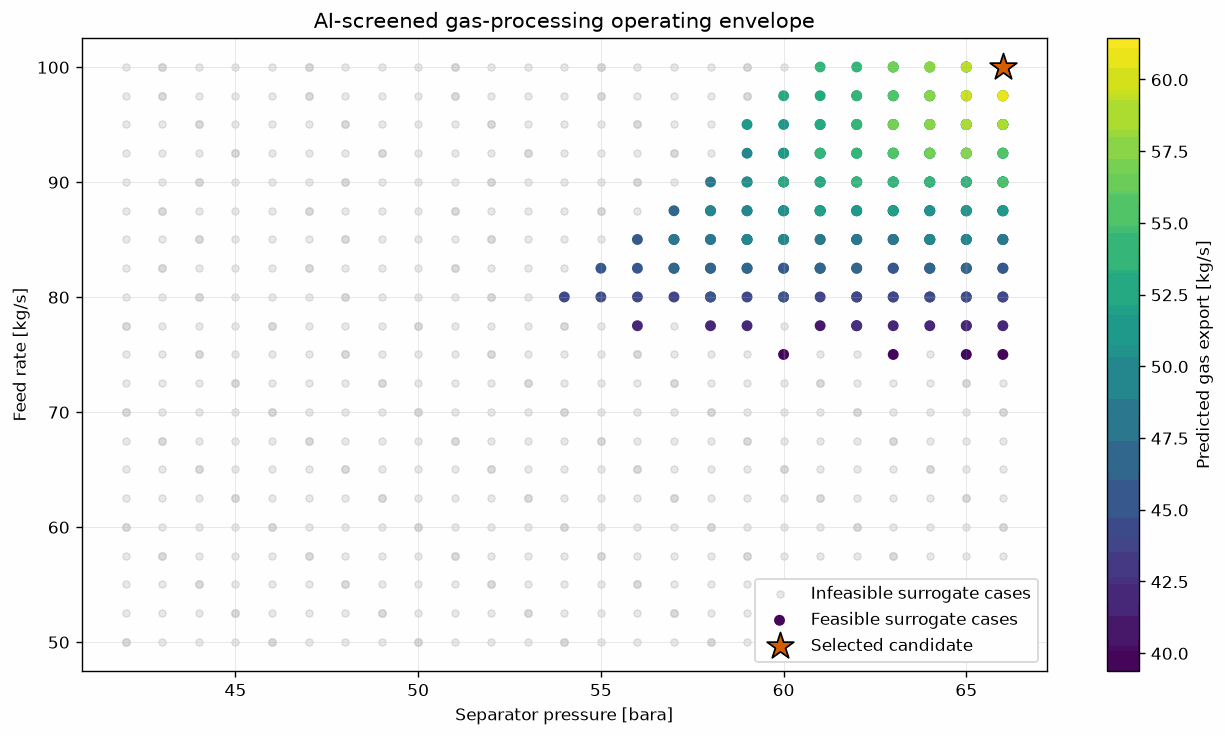

In [23]:
figure, axis = plt.subplots(figsize=(10.5, 6.0))

infeasible_sample = candidate_predictions.loc[
    ~candidate_predictions["feasible"]
].iloc[::20]
feasible_sample = feasible_candidates.iloc[::5]

axis.scatter(
    infeasible_sample["separator_pressure_bara"],
    infeasible_sample["feed_rate_kg_s"],
    color="#BDBDBD",
    alpha=0.35,
    s=18,
    label="Infeasible surrogate cases",
)
feasible_scatter = axis.scatter(
    feasible_sample["separator_pressure_bara"],
    feasible_sample["feed_rate_kg_s"],
    c=feasible_sample["gas_rate_kg_s"],
    cmap="viridis",
    s=28,
    label="Feasible surrogate cases",
)
axis.scatter(
    best_surrogate_candidate["separator_pressure_bara"],
    best_surrogate_candidate["feed_rate_kg_s"],
    marker="*",
    color=COLORS["red"],
    edgecolor="black",
    s=260,
    label="Selected candidate",
    zorder=5,
)
axis.set_title("AI-screened gas-processing operating envelope")
axis.set_xlabel("Separator pressure [bara]")
axis.set_ylabel("Feed rate [kg/s]")
axis.legend(loc="lower right")
colorbar = figure.colorbar(feasible_scatter, ax=axis)
colorbar.set_label("Predicted gas export [kg/s]")
figure.tight_layout()
plt.show()

## 15. Mandatory NeqSim verification

The recommended coordinates are rerun through fresh NeqSim objects. The constraints are
checked on the first-principles result, not merely on surrogate predictions. Small guard
margins are expected in real design work because an optimizer tends to approach active
constraints.

In [24]:
verified_candidate = run_neqsim_case(
    best_surrogate_candidate["feed_rate_kg_s"],
    best_surrogate_candidate["separator_pressure_bara"],
    best_surrogate_candidate["separator_temperature_k"],
)
verified_candidate_frame = pd.DataFrame([verified_candidate])

comparison_rows = []
for target_name in TARGET_COLUMNS:
    predicted_value = best_surrogate_candidate[target_name]
    verified_value = verified_candidate[target_name]
    comparison_rows.append(
        {
            "quantity": target_name,
            "surrogate": predicted_value,
            "NeqSim verification": verified_value,
            "difference": predicted_value - verified_value,
        }
    )

verification_comparison = pd.DataFrame(comparison_rows)
display(verification_comparison.round(6))

,quantity,surrogate,NeqSim verification,difference
0,gas_rate_kg_s,61.436269,61.511656,-0.075387
1,liquid_rate_kg_s,38.563731,38.488344,0.075387
2,compressor_power_mw,4.712334,4.726380,-0.014046
3,compressor_outlet_temperature_k,359.145790,359.091586,0.054204


In [25]:
verified_relative_mass_residual = abs(
    verified_candidate["mass_residual_kg_s"]
) / verified_candidate["feed_rate_kg_s"]
verified_power_margin_mw = 4.75 - verified_candidate["compressor_power_mw"]
verified_temperature_margin_k = (
    375.0 - verified_candidate["compressor_outlet_temperature_k"]
)
verified_liquid_margin_kg_s = (
    verified_candidate["liquid_rate_kg_s"] - 35.0
)

assert verified_relative_mass_residual < 1.0e-9
assert verified_power_margin_mw >= 0.0
assert verified_temperature_margin_k >= 0.0
assert verified_liquid_margin_kg_s >= 0.0
assert (
    abs(
        best_surrogate_candidate["compressor_power_mw"]
        - verified_candidate["compressor_power_mw"]
    )
    < 0.08
)

print(f"Verified power margin: {verified_power_margin_mw:.6f} MW")
print(f"Verified temperature margin: {verified_temperature_margin_k:.6f} K")
print(f"Verified liquid-rate margin: {verified_liquid_margin_kg_s:.6f} kg/s")

Verified power margin: 0.023620 MW
Verified temperature margin: 15.908414 K
Verified liquid-rate margin: 3.488344 kg/s


**Engineering conclusion.** A feasible surrogate point is not accepted until the detailed
model confirms mass closure and every constraint. If verification failed, the correct next
step would be to add the failed point to the training set, refit, and repeat—not to relax
physics silently.

## 16. Synthetic residual monitoring

A surrogate can also estimate expected outputs at measured inputs. The residual
$r=y_{measured}-\hat{y}$ is scaled by held-out RMSE:

$$
z = \frac{r}{\mathrm{RMSE}}
$$

The example below adds small deterministic measurement noise and two explicit synthetic
faults. A threshold of $|z|>4$ is a teaching choice, not a safety-alarm setting.

In [26]:
monitoring_inputs = pd.DataFrame(
    [
        (70.0, 54.0, 298.15),
        (72.0, 54.0, 299.15),
        (74.0, 55.0, 300.15),
        (76.0, 56.0, 300.15),
        (78.0, 57.0, 301.15),
        (80.0, 58.0, 302.15),
        (82.0, 59.0, 303.15),
        (84.0, 60.0, 304.15),
    ],
    columns=INPUT_COLUMNS,
)

monitoring_truth = pd.DataFrame(
    [
        run_neqsim_case(*row)
        for row in monitoring_inputs.to_numpy()
    ]
)
monitoring_expected = predict_surrogate(monitoring_inputs)

In [27]:
power_noise_mw = np.array(
    [0.01, -0.02, 0.00, 0.02, -0.01, 0.01, -0.02, 0.00]
)
liquid_noise_kg_s = np.array(
    [0.05, -0.08, 0.02, 0.06, -0.04, 0.03, -0.05, 0.01]
)

measured_power_mw = (
    monitoring_truth["compressor_power_mw"].to_numpy()
    + power_noise_mw
)
measured_liquid_rate_kg_s = (
    monitoring_truth["liquid_rate_kg_s"].to_numpy()
    + liquid_noise_kg_s
)

measured_power_mw[5] += 0.80
measured_liquid_rate_kg_s[3] -= 3.50

power_z_score = (
    measured_power_mw
    - monitoring_expected["compressor_power_mw"].to_numpy()
) / power_rmse
liquid_rmse = validation_frame.loc[
    validation_frame["target"] == "liquid_rate_kg_s",
    "RMSE",
].iloc[0]
liquid_z_score = (
    measured_liquid_rate_kg_s
    - monitoring_expected["liquid_rate_kg_s"].to_numpy()
) / liquid_rmse

## 17. Visual 6 — residual indicators

The bars are dimensionless residual scores. Separate quantities are shown because a single
aggregate score can hide whether the inconsistency is energetic or material.

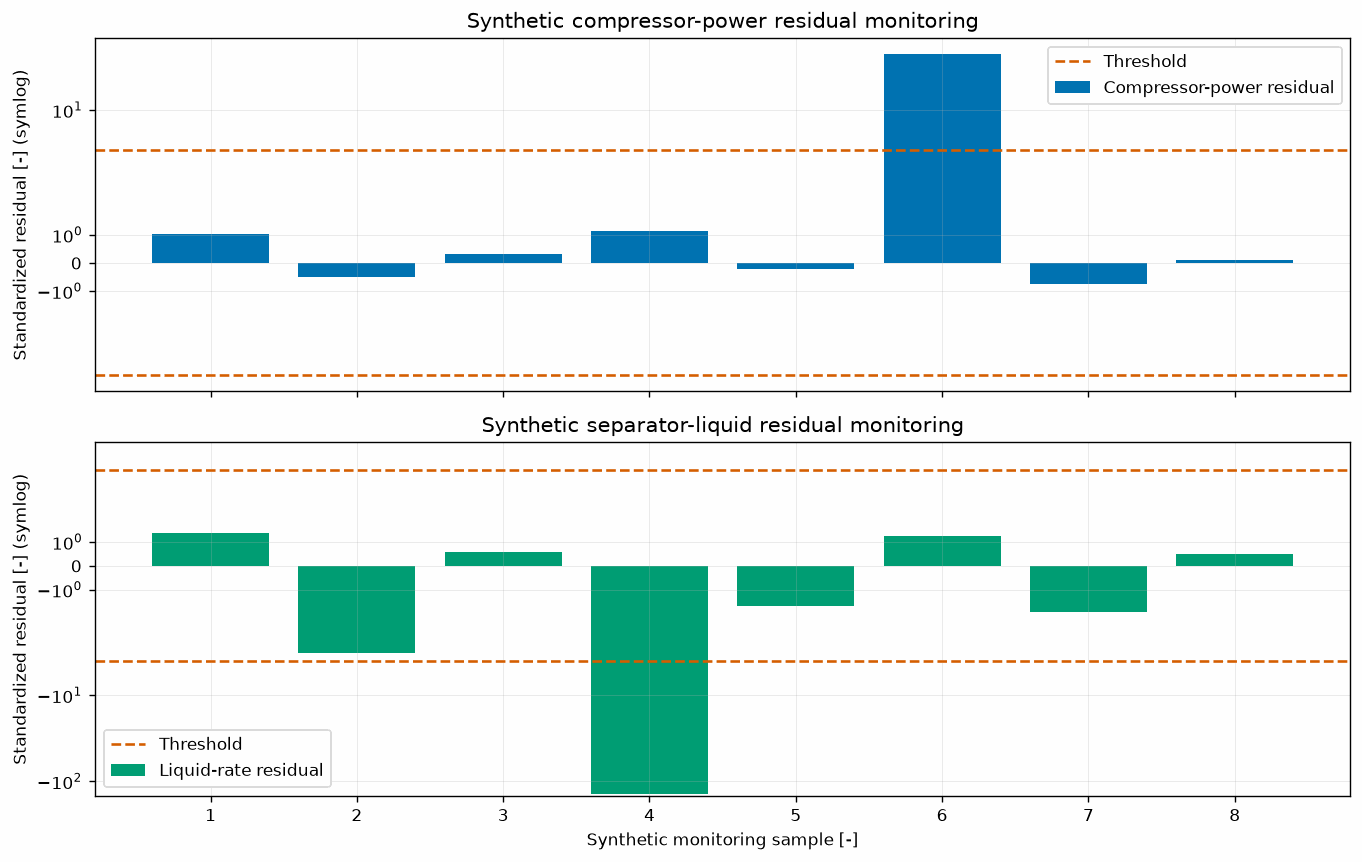

In [28]:
sample_index = np.arange(1, len(monitoring_inputs) + 1)
figure, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].bar(
    sample_index,
    power_z_score,
    color=COLORS["blue"],
    label="Compressor-power residual",
)
axes[0].axhline(4.0, color=COLORS["red"], linestyle="--", label="Threshold")
axes[0].axhline(-4.0, color=COLORS["red"], linestyle="--")
axes[0].set_yscale(
    "symlog",
    linthresh=4.0,
)
axes[0].set_title("Synthetic compressor-power residual monitoring")
axes[0].set_ylabel("Standardized residual [-] (symlog)")
axes[0].legend()

axes[1].bar(
    sample_index,
    liquid_z_score,
    color=COLORS["green"],
    label="Liquid-rate residual",
)
axes[1].axhline(4.0, color=COLORS["red"], linestyle="--", label="Threshold")
axes[1].axhline(-4.0, color=COLORS["red"], linestyle="--")
axes[1].set_yscale(
    "symlog",
    linthresh=4.0,
)
axes[1].set_title("Synthetic separator-liquid residual monitoring")
axes[1].set_xlabel("Synthetic monitoring sample [-]")
axes[1].set_ylabel("Standardized residual [-] (symlog)")
axes[1].legend()

figure.tight_layout()
plt.show()

In [29]:
power_anomaly_indices = np.flatnonzero(np.abs(power_z_score) > 4.0)
liquid_anomaly_indices = np.flatnonzero(np.abs(liquid_z_score) > 4.0)

assert 5 in power_anomaly_indices
assert 3 in liquid_anomaly_indices
assert len(power_anomaly_indices) == 1
assert len(liquid_anomaly_indices) == 1

print(
    "Detected synthetic power anomaly at sample:",
    int(power_anomaly_indices[0] + 1),
)
print(
    "Detected synthetic liquid anomaly at sample:",
    int(liquid_anomaly_indices[0] + 1),
)

Detected synthetic power anomaly at sample: 6
Detected synthetic liquid anomaly at sample: 4


**Interpretation.** The injected compressor-power and separator-liquid inconsistencies are
isolated in the expected channels. Real monitoring requires instrument validation, correlated
uncertainty, drift handling, persistence logic, and operator-approved alarm management.
Residuals alone do not diagnose root cause.

## 18. Trend and limiting-case checks

Before final acceptance, three independent cases at fixed pressure and temperature verify
that increasing feed raises gas rate, liquid rate, and compressor power. This focused
monotonic check would catch accidental unit swaps or reused mutable state even if the
regression metrics remained attractive.

In [30]:
trend_feed_rates = [55.0, 75.0, 95.0]
trend_results = [
    run_neqsim_case(
        feed_rate,
        58.0,
        300.15,
    )
    for feed_rate in trend_feed_rates
]
trend_frame = pd.DataFrame(trend_results)

assert np.all(np.diff(trend_frame["gas_rate_kg_s"]) > 0.0)
assert np.all(np.diff(trend_frame["liquid_rate_kg_s"]) > 0.0)
assert np.all(np.diff(trend_frame["compressor_power_mw"]) > 0.0)
assert (
    trend_frame["mass_residual_kg_s"].abs().max()
    / trend_frame["feed_rate_kg_s"].max()
    < 1.0e-9
)

display(
    trend_frame[
        [
            "feed_rate_kg_s",
            "gas_rate_kg_s",
            "liquid_rate_kg_s",
            "compressor_power_mw",
        ]
    ].round(6)
)

,feed_rate_kg_s,gas_rate_kg_s,liquid_rate_kg_s,compressor_power_mw
0,55.0,32.276191,22.723809,3.094214
1,75.0,44.012987,30.987013,4.219382
2,95.0,55.749784,39.250216,5.344551


## 19. Validation summary

The final gate consolidates execution evidence in one machine-readable table. It does not
replace the detailed assertions above.

In [31]:
validation_summary = pd.DataFrame(
    [
        ("Training NeqSim cases", len(training_frame), "cases"),
        ("Held-out NeqSim cases", len(test_frame), "cases"),
        ("Minimum held-out R²", minimum_r_squared, "-"),
        ("Power RMSE", power_rmse, "MW"),
        ("Gas-rate RMSE", gas_rate_rmse, "kg/s"),
        (
            "Maximum relative mass residual",
            maximum_relative_mass_residual,
            "-",
        ),
        (
            "Verified gas export",
            verified_candidate["gas_rate_kg_s"],
            "kg/s",
        ),
        ("Verified power margin", verified_power_margin_mw, "MW"),
        (
            "Verified temperature margin",
            verified_temperature_margin_k,
            "K",
        ),
        (
            "Verified liquid-rate margin",
            verified_liquid_margin_kg_s,
            "kg/s",
        ),
    ],
    columns=["check", "value", "unit"],
)

display(validation_summary.round(6))
print("All AI-gas-processing engineering checks passed.")

All AI-gas-processing engineering checks passed.


,check,value,unit
0,Training NeqSim cases,60.000000,cases
1,Held-out NeqSim cases,12.000000,cases
2,Minimum held-out R²,0.999714,-
3,Power RMSE,0.022866,MW
4,Gas-rate RMSE,0.024592,kg/s
5,Maximum relative mass residual,0.000000,-
6,Verified gas export,61.511656,kg/s
7,Verified power margin,0.023620,MW
8,Verified temperature margin,15.908414,K
9,Verified liquid-rate margin,3.488344,kg/s


## 20. Troubleshooting

* **Java is unavailable:** use a standard Google Colab runtime and rerun the setup cell.
* **A phase product is absent:** the chosen composition or state may be single- or two-phase;
  do not index an assumed phase without checking it.
* **The surrogate fails validation:** add physically relevant NeqSim cases, reduce the input
  domain, change the model form, and rerun held-out validation.
* **The optimizer fails NeqSim verification:** reject the recommendation, add the point to
  the training set, introduce guard margins, and repeat.
* **A residual crosses its threshold:** first check sensors, units, timestamps, and process
  mode; a statistical residual is not a diagnosis or safety trip.
* **Runtime is long:** reduce the factorial resolution for exploration, but restore the full
  design before relying on the published accuracy checks.

## 21. Applicability and limitations

This workflow is suitable for teaching hybrid modeling, rapid interpolation, scenario
ranking, and proof-of-concept monitoring. It is not a validated plant digital twin.
Important limitations include synthetic composition and measurements, one equation of state,
fixed compressor efficiency, equilibrium separation, no compressor map, no recycle,
no uncertainty interval, and no time dynamics. Extrapolation beyond the declared bounds is
prohibited because polynomial responses can become nonphysical.

## 22. Summary

NeqSim supplies thermodynamic and process consistency; the surrogate supplies speed. The
notebook generated 60 training and 12 held-out NeqSim cases, fitted an interpretable
multi-response model, quantified its error in engineering units, screened a constrained
operating envelope, independently reran the selected point, and demonstrated clearly labeled
synthetic residual monitoring. The central practice is simple: **AI proposes; physics,
engineering constraints, and verification decide.**

## 23. Further exercises

1. Add inlet pressure and gas composition as inputs, then redesign the sampling plan.
2. Compare the quadratic model with a Gaussian process or tree ensemble using the same split.
3. Add a compressor map and penalize surge or stonewall proximity.
4. Use bootstrap resampling to estimate prediction intervals.
5. Replace synthetic monitoring noise with a public, time-aligned dataset and document data
   provenance.
6. Implement active learning: add the highest-uncertainty candidate, rerun NeqSim, and refit.

References:

* [NeqSim documentation](https://equinor.github.io/neqsim/)
* [NeqSim process simulation guide](https://equinor.github.io/neqsim/process/)
* [NeqSim Java API](https://equinor.github.io/neqsim/javadoc/index.html)
* [scikit-learn guidance on common machine-learning pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)
* [NIST/SEMATECH e-Handbook: process modeling](https://www.itl.nist.gov/div898/handbook/pmd/pmd.htm)
* Original conceptual reference retained from this notebook:
  [ChatGPT](https://chat.openai.com/)